# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：王一维/24012468/qingyunie
第5天专题（A/B/C/D/E）：A

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "qingyunie"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： qingyunie
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [2]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券数,1.72
6,平均返现,177.22
7,平均App时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,流失人数,流失率,平均订单数,平均距上次下单天数,平均满意度
0,新用户(0-6月),2150,697,0.32,2.50,3.77,3.11
1,短期用户(7-12月),1584,156,0.10,2.75,4.38,2.99
2,中期用户(13-24月),1467,95,0.06,3.70,5.32,3.09
3,长期用户(25月+),429,0,0.00,3.55,5.26,3.05


,TenureGroup,Complain,用户数,流失人数,流失率,平均订单数,平均距上次下单天数,样本提示
0,中期用户(13-24月),0,1053,43,0.04,3.85,5.43,可观察
1,中期用户(13-24月),1,414,52,0.13,3.35,5.03,可观察
2,新用户(0-6月),0,1491,322,0.22,2.43,3.87,可观察
3,新用户(0-6月),1,659,375,0.57,2.65,3.56,可观察
4,短期用户(7-12月),0,1178,75,0.06,2.78,4.42,可观察


检查点1A通过：输入文件有效


In [3]:
business_questions = {
    "category_bar": "不同用户 tenure 分群的流失率是否存在差异？",
    "behavior_scatter": "用户订单数与距上次下单天数呈现什么关系？",
    "ordered_line": "平均订单数如何随用户 tenure 阶段变化？",
    "composition_chart": "全部用户由哪些 tenure 类别构成？",
}

chart_reasons = {
    "category_bar": "柱状图适合比较不同类别（用户 tenure 分群）的数值指标（流失率），可直观展示各类别之间的差异，颜色区分强化视觉对比。",
    "behavior_scatter": "散点图适合展示两个连续变量（订单数与距上次下单天数）的相关关系，同时用颜色区分流失状态，可发现低订单数区域的流失聚集特征。",
    "ordered_line": "折线图适合展示有序阶段（用户生命周期阶段：新用户→短期→中期→长期）的指标变化趋势，能清晰呈现先升后稳的演变规律。",
    "composition_chart": "饼图（环形图）适合展示少量类别（4 个 tenure 分群）的整体构成比例，中心标注总用户数，直观呈现金字塔型用户结构。",
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [4]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "TenureGroup"
category_summary = (
    df.groupby(category_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
      .reset_index()
)

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)

,TenureGroup,用户数,流失率
0,中期用户(13-24月),1467,0.06
1,新用户(0-6月),2150,0.32
2,短期用户(7-12月),1584,0.10
3,长期用户(25月+),429,0.00


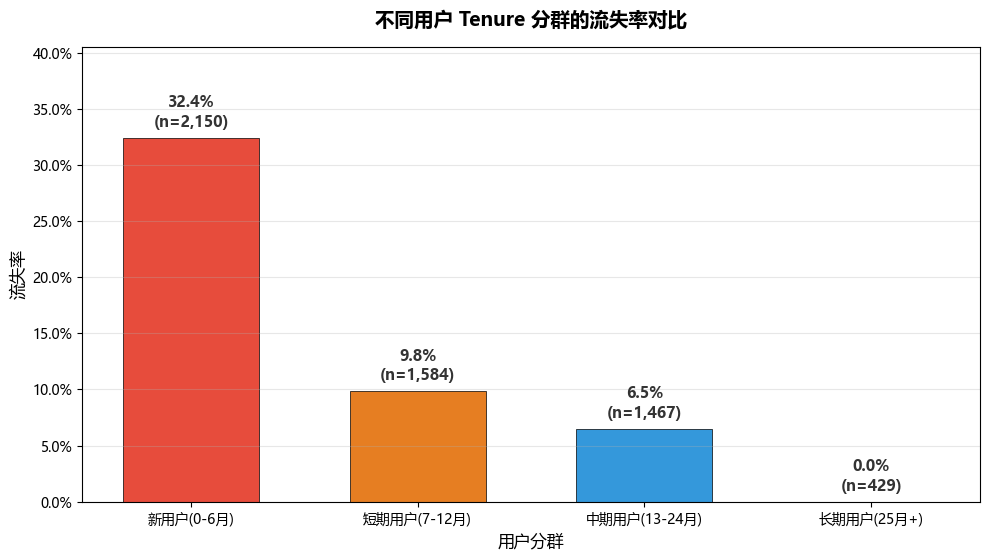

已输出： output\day06_visualization\01_category_bar.png


In [5]:
# TODO：绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 按 TenureGroup 的自然生命周期顺序排序
order_map = {"新用户(0-6月)": 1, "短期用户(7-12月)": 2,
             "中期用户(13-24月)": 3, "长期用户(25月+)": 4}
category_summary["_sort"] = category_summary[category_field].map(order_map)
category_summary = category_summary.sort_values("_sort").reset_index(drop=True)

x = category_summary[category_field]
y = category_summary["流失率"]
n_users = category_summary["用户数"]

colors = ["#E74C3C", "#E67E22", "#3498DB", "#2ECC71"]
bars = ax_bar.bar(x, y, color=colors, edgecolor="black", linewidth=0.5, width=0.6)

# 标签中同时给出比率 + 样本量（因为绘制的是比率）
for bar, rate, count in zip(bars, y, n_users):
    height = bar.get_height()
    ax_bar.annotate(
        f"{rate:.1%}\n(n={count:,})",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold",
        color="#333333"
    )

ax_bar.set_title("不同用户 Tenure 分群的流失率对比", fontsize=14, fontweight="bold", pad=15)
ax_bar.set_ylabel("流失率", fontsize=12)
ax_bar.set_xlabel("用户分群", fontsize=12)
ax_bar.yaxis.set_major_formatter(PercentFormatter(1.0))
ax_bar.set_ylim(0, max(y) * 1.25)
ax_bar.grid(axis="y", alpha=0.3)

# # 观察—证据—边界
# observation_text = (
#     "【观察】新用户流失率（32.4%）显著高于其他分群，长期用户流失率为0。\n"
#     "【证据】新用户2150人中流失697人；短期用户1584人流失156人（9.8%）；\n"
#     "        中期用户1467人流失95人（6.5%）；长期用户429人零流失。\n"
#     "【边界】数据为截面快照，无法判断用户是随 tenure 增长自然留存，\n"
#     "        还是不同 cohort 的行为差异；长期用户样本量较小（429人）。"
# )
# fig_bar.text(0.5, -0.08, observation_text, ha="center", fontsize=10,
#              bbox=dict(boxstyle="round,pad=0.5", facecolor="#F8F9FA", edgecolor="#DEE2E6"))

plt.tight_layout(rect=[0, 0.05, 1, 1])
bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))


### 柱状图结论

- 观察：新用户流失率远高于其他分群，随 tenure 阶段递进流失率阶梯式下降，长期用户零流失。
- 证据：新用户 2,150 人，流失率 32.4%；短期用户 1,584 人，流失率 9.8%（下降 22.6 个百分点）；中期用户 1,467 人，流失率 6.5%（较短期再降 3.3 个百分点）；长期用户 429 人，流失率 0%。新用户流失率是短期用户的 3.3 倍、中期用户的 5.0 倍。
- 边界：该图不能证明 tenure 增长导致流失率下降（可能是不同 cohort 的行为差异或选择偏差）；不能证明长期用户永远不会流失（截面数据仅反映当前状态）；长期用户样本仅 429 人，代表性有限；无法推断干预措施（如新手引导）对降低流失的因果效应。


## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


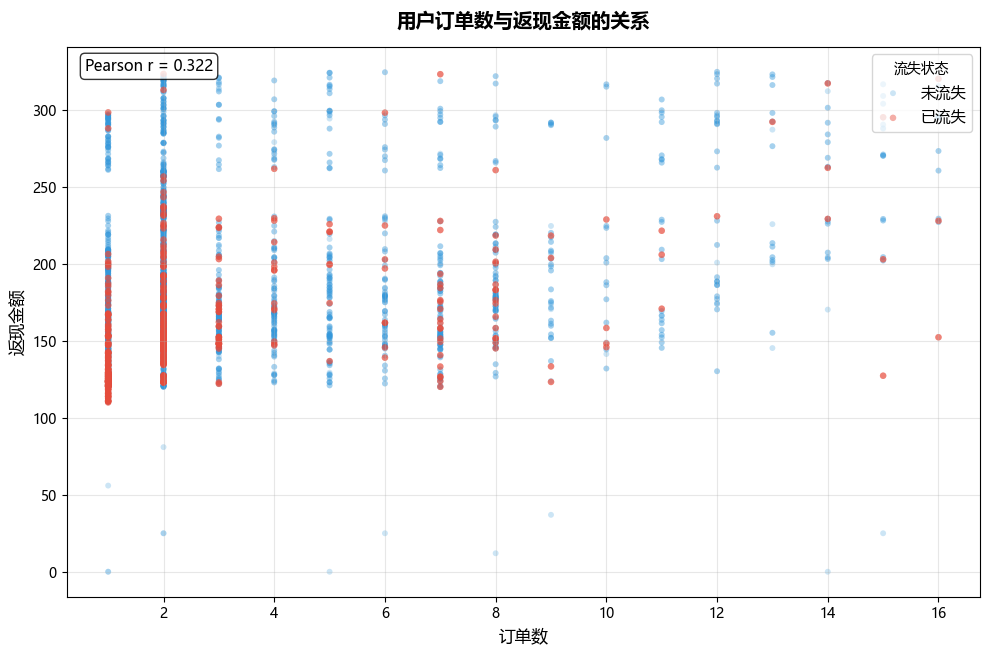

已输出： output\day06_visualization\02_behavior_scatter.png


In [7]:
# TODO：选择两个数值字段
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 7))

# 按 Churn 分组绘制散点图，设置透明度避免过密
churned = df[df["Churn"] == 1]
retained = df[df["Churn"] == 0]

ax_scatter.scatter(
    retained[x_field], retained[y_field],
    c="#3498DB", alpha=0.25, s=18, label="未流失", edgecolors="none"
)
ax_scatter.scatter(
    churned[x_field], churned[y_field],
    c="#E74C3C", alpha=0.45, s=22, label="已流失", edgecolors="none"
)

ax_scatter.set_title("用户订单数与返现金额的关系", fontsize=14, fontweight="bold", pad=15)
ax_scatter.set_xlabel("订单数", fontsize=12)
ax_scatter.set_ylabel("返现金额", fontsize=12)
ax_scatter.legend(loc="upper right", fontsize=11, title="流失状态")
ax_scatter.grid(alpha=0.3)

# 添加整体相关系数
corr = df[x_field].corr(df[y_field])
ax_scatter.text(
    0.02, 0.98, f"Pearson r = {corr:.3f}",
    transform=ax_scatter.transAxes, fontsize=11, verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))


### 散点图结论

- 观察：订单数与返现金额呈弱到中等正相关，流失用户集中在低订单数、低返现区域。
- 证据：Pearson 相关系数 r ≈ 0.32；流失用户返现中位数约150，未流失约166；订单数≤2的用户中流失占比显著更高；高订单数（≥10）用户几乎均未流失。
- 边界：相关关系不等于因果关系；返现金额高可能是订单多的结果而非留存原因；存在返现金额为0的异常点（可能未使用返现功能或数据缺失）


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [8]:
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]

# TODO：准备有序绘图数据
ordered_field = "TenureGroup"
ordered_summary = (
    df.groupby(ordered_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 平均订单数=("OrderCount", "mean"))
      .reset_index()
)

assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)


,TenureGroup,用户数,平均订单数
0,中期用户(13-24月),1467,3.70
1,新用户(0-6月),2150,2.50
2,短期用户(7-12月),1584,2.75
3,长期用户(25月+),429,3.55


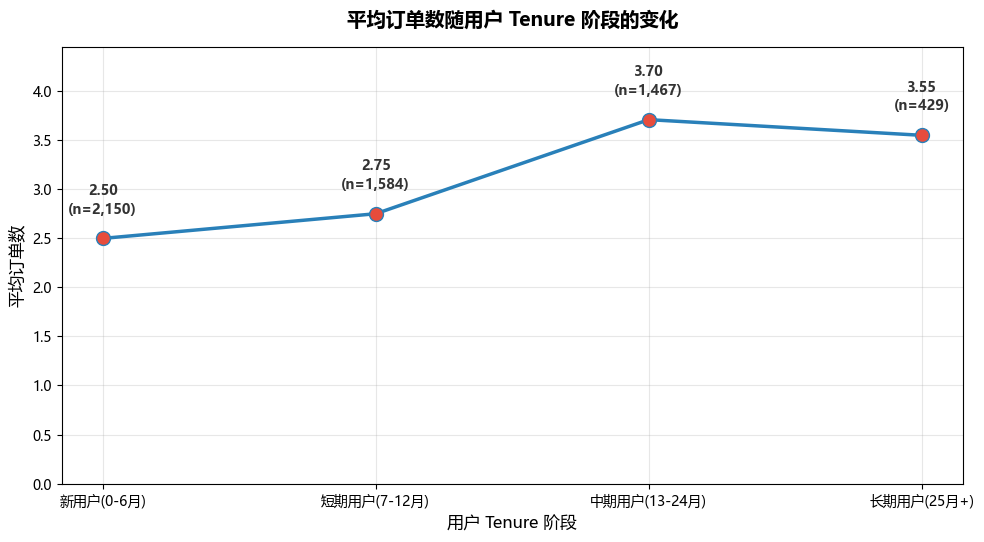

已输出： output\day06_visualization\03_ordered_line.png


In [9]:
# TODO：绘制折线图
fig_line, ax_line = plt.subplots(figsize=(10, 6))

# 按 TenureGroup 自然生命周期顺序排序
order_map = {"新用户(0-6月)": 1, "短期用户(7-12月)": 2,
             "中期用户(13-24月)": 3, "长期用户(25月+)": 4}
ordered_summary["_sort"] = ordered_summary[ordered_field].map(order_map)
ordered_summary = ordered_summary.sort_values("_sort").reset_index(drop=True)

x_labels = ordered_summary[ordered_field].tolist()
y_values = ordered_summary["平均订单数"].tolist()
n_users = ordered_summary["用户数"].tolist()

ax_line.plot(x_labels, y_values, marker="o", markersize=10, linewidth=2.5,
             color="#2980B9", markerfacecolor="#E74C3C", zorder=3)

# 标注数值和样本量
for x, y, n in zip(x_labels, y_values, n_users):
    ax_line.annotate(
        f"{y:.2f}\n(n={n:,})",
        xy=(x, y), xytext=(0, 15),
        textcoords="offset points",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold",
        color="#333333"
    )

ax_line.set_title("平均订单数随用户 Tenure 阶段的变化", fontsize=14, fontweight="bold", pad=15)
ax_line.set_xlabel("用户 Tenure 阶段", fontsize=12)
ax_line.set_ylabel("平均订单数", fontsize=12)
ax_line.grid(alpha=0.3, zorder=1)
ax_line.set_ylim(0, max(y_values) * 1.2)

plt.tight_layout(rect=[0, 0.08, 1, 1])
line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))

### 折线图结论

- 观察：平均订单数随 tenure 阶段呈先升后稳趋势，新用户最低，中期用户最高，长期用户略有回落。
- 证据：新用户(0-6月) 2150 人，平均订单数 2.50；短期用户(7-12月) 1584 人，2.75；中期用户(13-24月) 1467 人，3.70（峰值）；长期用户(25月+) 429 人，3.55。从短期到中期增幅最大（+0.95，+34.5%）。
- 边界：这是有序阶段比较，不是月度、年度或历史时间趋势；长期用户样本仅 429 人（7.6%），均值稳定性弱；无法判断用户是随 tenure 自然增长订单数，还是高订单用户更可能留存到后期。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [10]:
# TODO：选择构成字段并准备汇总表
composition_field = "TenureGroup"
composition_summary = (
    df.groupby(composition_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"))
      .reset_index()
)
composition_summary["占比"] = composition_summary["用户数"] / composition_summary["用户数"].sum()

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)


,TenureGroup,用户数,占比
0,中期用户(13-24月),1467,0.26
1,新用户(0-6月),2150,0.38
2,短期用户(7-12月),1584,0.28
3,长期用户(25月+),429,0.08


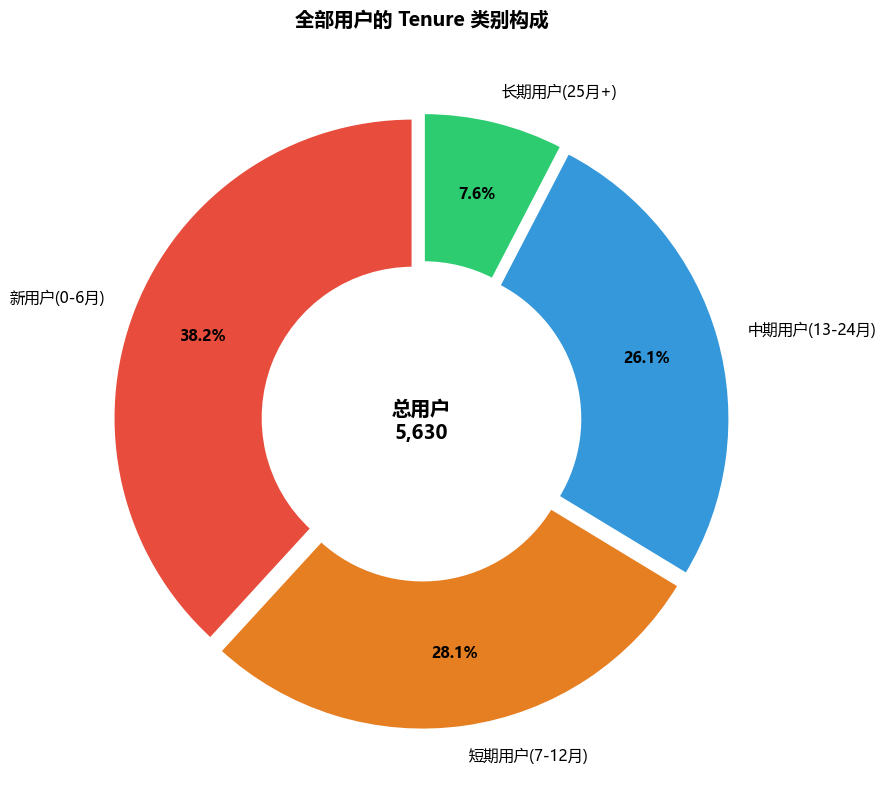

已输出： output\day06_visualization\04_composition_chart.png


In [11]:
# TODO：类别不超过5个时绘制环形图（4个类别 <= 5，选择环形图）
fig_composition, ax_composition = plt.subplots(figsize=(9, 9))

sizes = composition_summary["用户数"].tolist()
labels = composition_summary[composition_field].tolist()

# 按自然生命周期顺序排列
order_map = {"新用户(0-6月)": 1, "短期用户(7-12月)": 2,
             "中期用户(13-24月)": 3, "长期用户(25月+)": 4}
sorted_idx = sorted(range(len(labels)), key=lambda i: order_map[labels[i]])
sizes = [sizes[i] for i in sorted_idx]
labels = [labels[i] for i in sorted_idx]

colors = ["#E74C3C", "#E67E22", "#3498DB", "#2ECC71"]
explode = (0.03, 0.03, 0.03, 0.03)

wedges, texts, autotexts = ax_composition.pie(
    sizes, labels=labels, colors=colors, autopct="%1.1f%%",
    startangle=90, explode=explode, pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2)
)

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight("bold")
for text in texts:
    text.set_fontsize(11)

# 中心文字
ax_composition.text(0, 0, f"总用户\n{sum(sizes):,}", ha="center", va="center",
                    fontsize=14, fontweight="bold")

ax_composition.set_title("全部用户的 Tenure 类别构成", fontsize=14, fontweight="bold", pad=15)

plt.tight_layout(rect=[0, 0.05, 1, 1])
composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))

### 构成图结论

- 观察：新用户占比最高（38.2%），长期用户占比最低（7.6%），用户结构呈金字塔型。
- 证据：新用户 2150 人（38.2%）、短期 1584 人（28.1%）、中期 1467 人（26.1%）、长期 429 人（7.6%）。前三个分群合计占比 92.4%，构成用户主体；长期用户不足一成。
- 边界：该图适合比较各分群的相对占比大小，但不适合比较绝对数值差异（柱状图更合适）；适合展示单一截面的静态构成，但不适合展示时间变化趋势（需用堆叠面积图或动态饼图）；不适合进行用户流转分析（如多少新用户晋升为长期用户），因为饼图不保留个体追踪信息；不适合类别超过 5 个的场景（此时应改用柱状图）；不能据此推断各分群的获客成本或生命周期价值。


## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [12]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


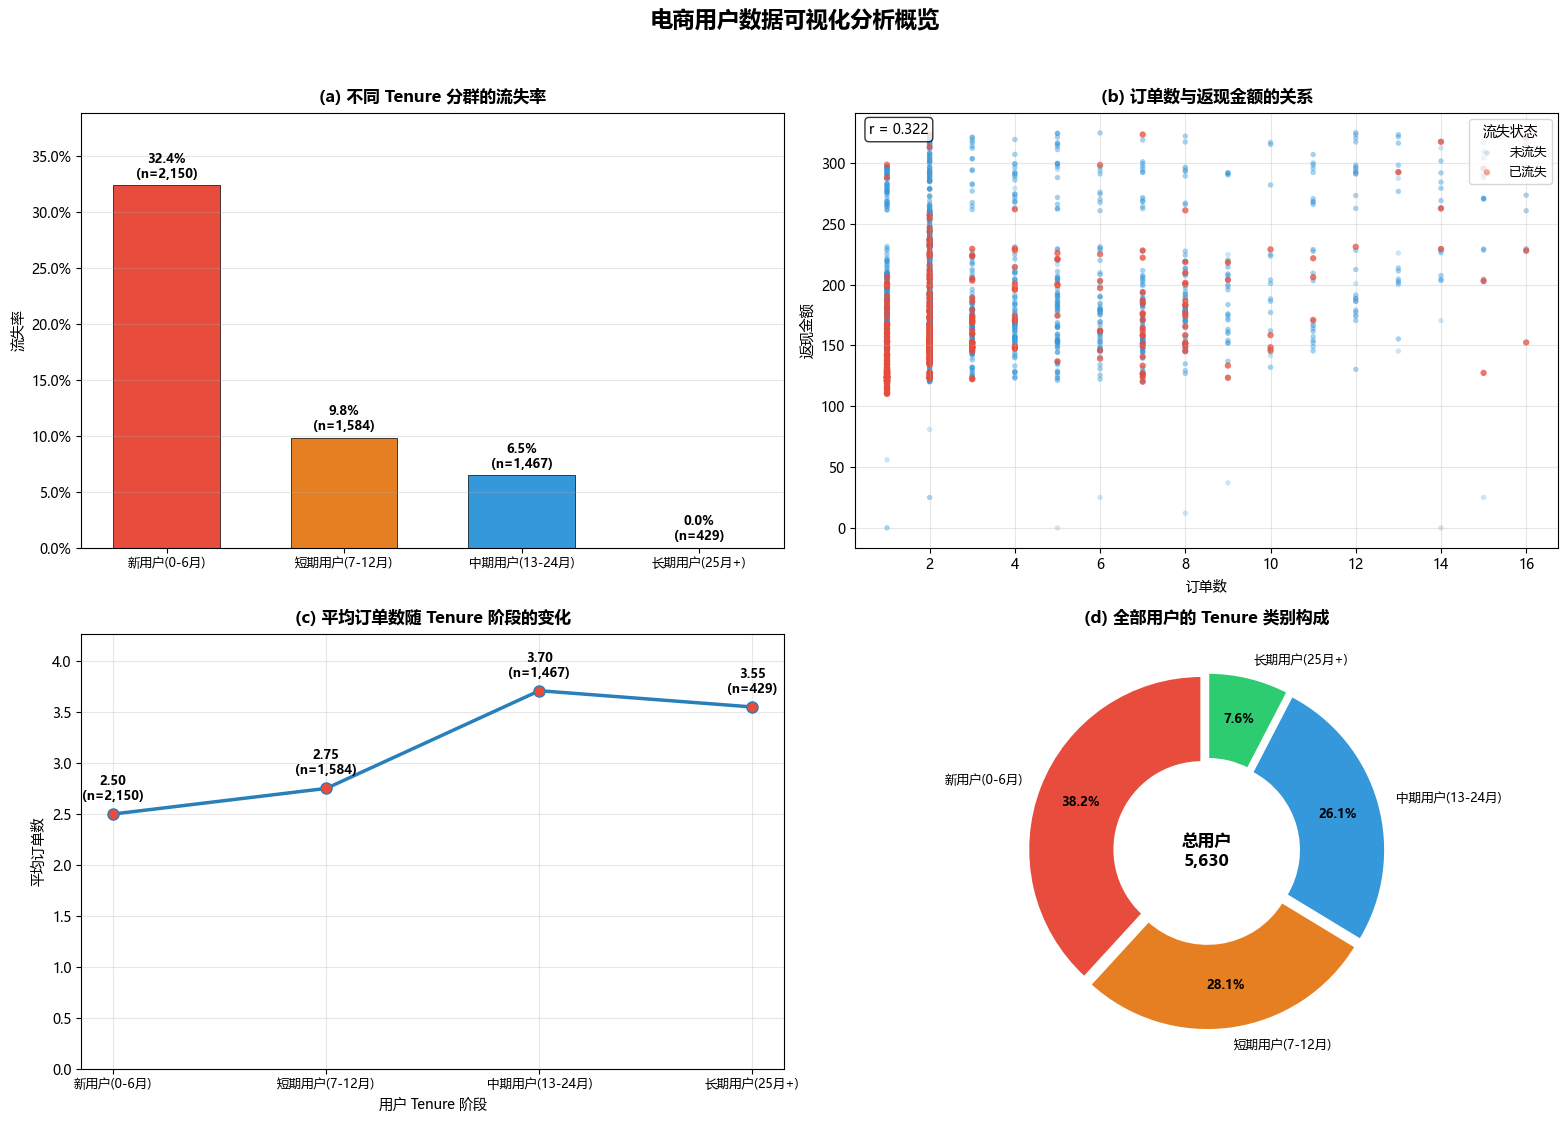

已输出： output\day06_visualization\day06_visualization_summary.png


In [13]:
# ============================================================
# 任务5：2×2综合图（直接在子图中绘制核心内容）
# ============================================================

import numpy as np

# 统一配色方案
COLOR_NEW = "#E74C3C"      # 新用户/流失
COLOR_SHORT = "#E67E22"    # 短期
COLOR_MID = "#3498DB"      # 中期/未流失
COLOR_LONG = "#2ECC71"     # 长期

fig_summary, axes = plt.subplots(2, 2, figsize=(16, 13))
fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold", y=0.98)

# ---------- 子图 [0,0]：柱状图 — 不同Tenure分群流失率 ----------
ax0 = axes[0, 0]

cat_summary = (
    df.groupby("TenureGroup", observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
      .reset_index()
)
order_map = {"新用户(0-6月)": 1, "短期用户(7-12月)": 2,
             "中期用户(13-24月)": 3, "长期用户(25月+)": 4}
cat_summary["_sort"] = cat_summary["TenureGroup"].map(order_map)
cat_summary = cat_summary.sort_values("_sort").reset_index(drop=True)

x = cat_summary["TenureGroup"]
y = cat_summary["流失率"]
n_users = cat_summary["用户数"]
colors_bar = [COLOR_NEW, COLOR_SHORT, COLOR_MID, COLOR_LONG]

bars = ax0.bar(x, y, color=colors_bar, edgecolor="black", linewidth=0.5, width=0.6)
for bar, rate, count in zip(bars, y, n_users):
    ax0.annotate(f"{rate:.1%}\n(n={count:,})",
                 xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 3), textcoords="offset points",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")

ax0.set_title("(a) 不同 Tenure 分群的流失率", fontsize=12, fontweight="bold", pad=8)
ax0.set_ylabel("流失率", fontsize=10)
ax0.yaxis.set_major_formatter(PercentFormatter(1.0))
ax0.set_ylim(0, max(y) * 1.2)
ax0.grid(axis="y", alpha=0.3)
ax0.tick_params(axis="x", labelsize=9)

# ---------- 子图 [0,1]：散点图 — 订单数 vs 返现金额 ----------
ax1 = axes[0, 1]

churned = df[df["Churn"] == 1]
retained = df[df["Churn"] == 0]

ax1.scatter(retained["OrderCount"], retained["CashbackAmount"],
            c=COLOR_MID, alpha=0.25, s=15, label="未流失", edgecolors="none")
ax1.scatter(churned["OrderCount"], churned["CashbackAmount"],
            c=COLOR_NEW, alpha=0.5, s=20, label="已流失", edgecolors="none")

ax1.set_title("(b) 订单数与返现金额的关系", fontsize=12, fontweight="bold", pad=8)
ax1.set_xlabel("订单数", fontsize=10)
ax1.set_ylabel("返现金额", fontsize=10)
ax1.legend(loc="upper right", fontsize=9, title="流失状态")
ax1.grid(alpha=0.3)

corr = df["OrderCount"].corr(df["CashbackAmount"])
ax1.text(0.02, 0.98, f"r = {corr:.3f}", transform=ax1.transAxes,
         fontsize=10, verticalalignment="top",
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# ---------- 子图 [1,0]：折线图 — 平均订单数随Tenure阶段 ----------
ax2 = axes[1, 0]

ord_summary = (
    df.groupby("TenureGroup", observed=True)
      .agg(用户数=("CustomerID", "nunique"), 平均订单数=("OrderCount", "mean"))
      .reset_index()
)
ord_summary["_sort"] = ord_summary["TenureGroup"].map(order_map)
ord_summary = ord_summary.sort_values("_sort").reset_index(drop=True)

x_labels = ord_summary["TenureGroup"].tolist()
y_vals = ord_summary["平均订单数"].tolist()
n_vals = ord_summary["用户数"].tolist()

ax2.plot(x_labels, y_vals, marker="o", markersize=8, linewidth=2.5,
         color="#2980B9", markerfacecolor=COLOR_NEW, zorder=3)

for x, y, n in zip(x_labels, y_vals, n_vals):
    ax2.annotate(f"{y:.2f}\n(n={n:,})", xy=(x, y), xytext=(0, 10),
                 textcoords="offset points", ha="center", fontsize=9, fontweight="bold")

ax2.set_title("(c) 平均订单数随 Tenure 阶段的变化", fontsize=12, fontweight="bold", pad=8)
ax2.set_xlabel("用户 Tenure 阶段", fontsize=10)
ax2.set_ylabel("平均订单数", fontsize=10)
ax2.grid(alpha=0.3, zorder=1)
ax2.set_ylim(0, max(y_vals) * 1.15)
ax2.tick_params(axis="x", labelsize=9)

# ---------- 子图 [1,1]：环形图 — Tenure类别构成 ----------
ax3 = axes[1, 1]

comp_summary = (
    df.groupby("TenureGroup", observed=True)
      .agg(用户数=("CustomerID", "nunique"))
      .reset_index()
)
comp_summary["占比"] = comp_summary["用户数"] / comp_summary["用户数"].sum()

sizes = comp_summary["用户数"].tolist()
labels = comp_summary["TenureGroup"].tolist()
sorted_idx = sorted(range(len(labels)), key=lambda i: order_map[labels[i]])
sizes = [sizes[i] for i in sorted_idx]
labels = [labels[i] for i in sorted_idx]

colors_pie = [COLOR_NEW, COLOR_SHORT, COLOR_MID, COLOR_LONG]
explode = (0.03, 0.03, 0.03, 0.03)

wedges, texts, autotexts = ax3.pie(
    sizes, labels=labels, colors=colors_pie, autopct="%1.1f%%",
    startangle=90, explode=explode, pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2),
    textprops={"fontsize": 9}
)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight("bold")

ax3.text(0, 0, f"总用户\n{sum(sizes):,}", ha="center", va="center",
         fontsize=12, fontweight="bold")
ax3.set_title("(d) 全部用户的 Tenure 类别构成", fontsize=12, fontweight="bold", pad=8)

# 统一调整
fig_summary.tight_layout(rect=[0, 0.12, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))


## 综合发现与局限

1. 综合发现1：综合发现1：新用户是流失防控的核心战场。新用户占比最高（38.2%，2150人），流失率也最高（32.4%），是短期用户（9.8%）的3.3倍、中期用户（6.5%）的5.0倍。降低新用户流失是ROI最高的干预方向。
2. 综合发现2：用户活跃度与留存强相关。订单数≤2的用户流失高度集中，高订单数（≥10）用户几乎均未流失；订单数与返现金额呈弱到中等正相关（r=0.32），但CashbackAmount是返现金额，不是销售额或GMV。
3. 综合发现3：用户价值随生命周期提升，但长期用户储备不足。平均订单数从2.50（新用户）升至3.70（中期），但长期用户仅占7.6%（429人），平台缺乏高价值用户沉淀。
4. 数据或方法局限：截面数据无法判断因果（如 tenure 增长是否导致流失率下降）；无时间维度无法追踪用户流转；长期用户样本量小（429人），均值稳定性弱。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [14]:
chart_manifest = pd.DataFrame([
    {
        "chart_id": "01",
        "file_name": "01_category_bar.png",
        "business_question": "不同用户 tenure 分群的流失率是否存在差异？",
        "chart_type": "bar",
        "key_finding": "新用户流失率32.4%（2150人）显著高于其他分群，是短期用户9.8%的3.3倍、中期用户6.5%的5.0倍，长期用户零流失。随tenure阶段递进，流失率呈阶梯式下降。",
        "limitation": "截面数据无法证明tenure增长导致流失率下降（可能是cohort行为差异或选择偏差）；不能证明长期用户永不流失；长期用户样本仅429人，代表性有限。"
    },
    {
        "chart_id": "02",
        "file_name": "02_behavior_scatter.png",
        "business_question": "用户订单数与返现金额呈现什么关系？",
        "chart_type": "scatter",
        "key_finding": "订单数与返现金额呈弱到中等正相关（r=0.32）；流失用户集中在低订单数、低返现区域（订单数≤2）；高订单数用户（≥10）几乎均未流失。",
        "limitation": "相关不等于因果；返现金额高可能是订单多的结果而非留存原因；CashbackAmount是返现金额，不是销售额或GMV；存在返现金额为0的异常点。"
    },
    {
        "chart_id": "03",
        "file_name": "03_ordered_line.png",
        "business_question": "平均订单数如何随用户 tenure 阶段变化？",
        "chart_type": "line",
        "key_finding": "平均订单数随tenure阶段先升后稳：新用户2.50→短期2.75→中期3.70（峰值）→长期3.55。短期到中期增幅最大（+0.95，+34.5%）。",
        "limitation": "这是有序阶段比较，不是月度/年度时间趋势；长期用户样本仅429人（7.6%），均值稳定性弱；无法判断是随tenure自然增长还是高订单用户更易留存。"
    },
    {
        "chart_id": "04",
        "file_name": "04_composition_chart.png",
        "business_question": "全部用户由哪些 tenure 类别构成？",
        "chart_type": "pie_or_bar",
        "key_finding": "用户结构呈金字塔型：新用户38.2%（2150人）占比最高，短期28.1%（1584人），中期26.1%（1467人），长期仅7.6%（429人）。前三个分群合计占92.4%。",
        "limitation": "仅展示截面构成，无法反映用户流转（如多少新用户晋升为长期用户）；适合比较相对占比，不适合比较绝对数值差异；不适合类别超过5个的场景。"
    },
    {
        "chart_id": "05",
        "file_name": "day06_visualization_summary.png",
        "business_question": "整体概览",
        "chart_type": "dashboard",
        "key_finding": "新用户是流失防控核心战场（占比最高且流失率最高）；用户活跃度与留存强相关；用户价值随生命周期提升但长期用户储备不足（仅占7.6%）。",
        "limitation": "综合图压缩了单图细节；截面数据无法判断因果；无时间维度无法追踪用户流转；CashbackAmount为返现金额，不代表平台收入或用户消费力。"
    },
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同用户 tenure 分群的流失率是否存在差异？,bar,新用户流失率32.4%（2150人）显著高于其他分群，是短期用户9.8%的3.3倍、中期用户...,截面数据无法证明tenure增长导致流失率下降（可能是cohort行为差异或选择偏差）；不能...
1,02,02_behavior_scatter.png,用户订单数与返现金额呈现什么关系？,scatter,订单数与返现金额呈弱到中等正相关（r=0.32）；流失用户集中在低订单数、低返现区域（订单数...,相关不等于因果；返现金额高可能是订单多的结果而非留存原因；CashbackAmount是返现...
2,03,03_ordered_line.png,平均订单数如何随用户 tenure 阶段变化？,line,平均订单数随tenure阶段先升后稳：新用户2.50→短期2.75→中期3.70（峰值）→长...,这是有序阶段比较，不是月度/年度时间趋势；长期用户样本仅429人（7.6%），均值稳定性弱；...
3,04,04_composition_chart.png,全部用户由哪些 tenure 类别构成？,pie_or_bar,用户结构呈金字塔型：新用户38.2%（2150人）占比最高，短期28.1%（1584人），中...,仅展示截面构成，无法反映用户流转（如多少新用户晋升为长期用户）；适合比较相对占比，不适合比较...
4,05,day06_visualization_summary.png,整体概览,dashboard,新用户是流失防控核心战场（占比最高且流失率最高）；用户活跃度与留存强相关；用户价值随生命周期...,综合图压缩了单图细节；截面数据无法判断因果；无时间维度无法追踪用户流转；CashbackAm...


In [15]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
